# dLEM quick-start: H1-hESC chr10

This notebook fits a **dLEM** (Differentiable Loop Extrusion Model) to a small H1-hESC
Hi-C dataset and reproduces the reference locus contact map at **chr10:20.5-22.5 Mb**
(10 kb resolution), including a CTCF alignment check.

**Data**: 700 bins (7 Mb) extracted from `4DNFI9GMP2J8` (H1-hESC, 4D Nucleome), stored as
`data/example_chr10.cool`. The chromosome is named `ref_region` with coordinates starting
at 0; bin 0 corresponds to chr10:19,000,000 (see `data/create_example_data.py`). The
matching CTCF track (`data/example_ctcf.tsv`, from Maria's H1-hESC "painted" CTCF track)
covers the same window (see `data/create_example_ctcf.py`).

**To run without a Jupyter server**, the same workflow is available from the command line
(installed via `pip install -e .`):

```
dlem data/example_chr10.cool /tmp/out --chrom ref_region --resolution 10000 \
    --width 700 --train-to 200 --ctcf-tsv data/example_ctcf.tsv --plot --plot-span 200
```


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from IPython.display import Image, display

import dlem
from dlem.viz import band_to_dense, _resolve_cmap
print('dlem loaded from:', dlem.__file__)


INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


[dlem] NVIDIA GPU detected but JAX is running on CPU.
       For GPU acceleration reinstall with:
           pip install "dlem-jax[cuda]"

dlem loaded from: /home/tis97/dlem/dlem/__init__.py


## 1. Load data

`dlem.load_band` applies adaptive coarse-graining and along-diagonal NaN interpolation
(cached to `band_cache/`), returning a `(700 diagonals x 700 bins)` band matrix.


In [2]:
COOL       = 'data/example_chr10.cool'
CTCF_TSV   = 'data/example_ctcf.tsv'
CHROM      = 'ref_region'
RESOLUTION = 10_000
WIDTH      = 700     # full window loaded (matches example_chr10.cool)

# Offset for converting local bin positions to true chr10 coordinates
GENOMIC_OFFSET_MB = 19.0
GENOMIC_OFFSET_BP = int(GENOMIC_OFFSET_MB * 1e6)

band = dlem.load_band(COOL, resolution=RESOLUTION, chrom=CHROM, width=WIDTH)
print(f'band shape: {band.shape},  dtype: {band.dtype}')


[band] cache hit /home/tis97/dlem/band_cache/band_ref_region_10000_700_1241ac6cc9d0dcc8.npy
band shape: (700, 700),  dtype: float32


## 2. Fit dLEM

The single supported method: optimize `L`, `R` directly with Adam under the per-diagonal
multinomial loss on the self-normalizing full rollout (`dlem.fit`). `train_to=200` (rather
than the `train_to=100` convention used elsewhere) is a deliberate choice for this specific
example: it matches the reference locus's full 2 Mb plotted span below, so the fit has
genuine trained depth there rather than extrapolating past what it was optimized on.

`fit.checkpoints` keeps every checkpoint (`mse`/`corr`/`loss`/`symm`/`symm2`) from this one
optimization; `monitor` picks which becomes `fit.L`/`fit.R`. `symm2` (default) is the
velocity-elbow checkpoint -- where the Adam parameter motion hands off from the symmetric
to the antisymmetric subspace -- an interpretable, CTCF-aligned fit with no mse budget to
tune; see `dlem/train.py`'s `run_adam` docstring for the full derivation.


In [3]:
fit = dlem.fit(
    band, s=0.025, train_to=200,
    importance_power=0.5, diag_weight_power=1.0,
    n_opt=1500, verbose=True,
)
print(f'mse={fit.mse:.4f}  corr={fit.corr:.4f}  checkpoint={fit.monitor}')


  [   0] loss=6.4866  mse=0.3708  corr=0.5579  corr(L,R)=+0.5931
  [  25] loss=6.3794  mse=0.2462  corr=0.6101  corr(L,R)=+0.6010
  [  50] loss=6.3008  mse=0.2026  corr=0.6780  corr(L,R)=+0.6396
  [  75] loss=6.2597  mse=0.2845  corr=0.7242  corr(L,R)=+0.6340
  [ 100] loss=6.2561  mse=0.2853  corr=0.7387  corr(L,R)=+0.6006
  [ 125] loss=6.2555  mse=0.2936  corr=0.7390  corr(L,R)=+0.5900
  [ 150] loss=6.2554  mse=0.2939  corr=0.7398  corr(L,R)=+0.5816
  [ 175] loss=6.2553  mse=0.2944  corr=0.7402  corr(L,R)=+0.5753
  [ 200] loss=6.2552  mse=0.2945  corr=0.7404  corr(L,R)=+0.5691
  [ 225] loss=6.2552  mse=0.2945  corr=0.7407  corr(L,R)=+0.5624
  [ 250] loss=6.2551  mse=0.2946  corr=0.7408  corr(L,R)=+0.5549
  [ 275] loss=6.2551  mse=0.2946  corr=0.7409  corr(L,R)=+0.5470
  [ 300] loss=6.2551  mse=0.2947  corr=0.7410  corr(L,R)=+0.5393
  [ 325] loss=6.2550  mse=0.2949  corr=0.7411  corr(L,R)=+0.5322
  [ 350] loss=6.2550  mse=0.2950  corr=0.7411  corr(L,R)=+0.5259
  [ 375] loss=6.2550  mse

## 3. CTCF alignment

Barriers (dips in `L`/`R`) are expected to anti-correlate with CTCF, split by motif
strand: `L`~CTCF+, `R`~CTCF- (`L`/`R` index the left/right-moving anchor respectively --
see `dlem/model.py`'s module docstring). `checkpoint="all"` compares every checkpoint from
the fit above without re-fitting.


In [4]:
cpos, cneg = dlem.load_ctcf_tsv(CTCF_TSV, CHROM)
_ = dlem.ctcf_report(fit, cpos, cneg, max_lag=2, checkpoint='all')


CTCF correlation (anti-correlation expected; L~CTCF+, R~CTCF-), max_lag=2:
  checkpoint    L.CTCF+  L.CTCF-  R.CTCF+  R.CTCF-
  mse            -0.310   -0.255   -0.262   -0.279
  corr           -0.222   -0.172   -0.221   -0.248
  loss           -0.222   -0.172   -0.221   -0.248
  symm           -0.310   -0.255   -0.262   -0.279
  symm2          -0.269   -0.212   -0.236   -0.267 *


## 4. Example-patch plot helper

Same double-triangle convention used throughout `~/dlemFR_eval` (`figure_fig2_performance_simplified.ipynb`
cell 8, there called "patootie"): `patch[p,q]` = data O/E for `q >= p` (upper triangle),
model O/E for `q < p` (lower triangle); `L` track (blue) above sharing the genomic x-axis,
`R` track (orange) to the right sharing the genomic y-axis. `offset_bp` shifts the axis
labels from local `ref_region` coordinates to true chr10 coordinates (this example window
starts at chr10:19 Mb).


In [5]:
def plot_example_patch(fit, band, start, span, res, chrom, label, *, checkpoint=None,
                  out=None, seam_row=None, offset_bp=0):
    """seam_row: if given (e.g. fit.train_to when span > fit.train_to), draws a dashed
    guide line in the model (lower) triangle marking the genomic distance beyond which the
    full rollout is extrapolating past what was actually optimized."""
    L, R = fit._LR(checkpoint)

    data_oe_band = dlem.normalize_oe(band)
    model_oe_band = dlem.normalize_oe(fit.predict(span, checkpoint=checkpoint))

    data_dense = band_to_dense(np.asarray(data_oe_band), start, start + span)
    model_dense = band_to_dense(np.asarray(model_oe_band), start, start + span)
    patch = np.triu(data_dense) + np.tril(model_dense, k=-1)

    v = float(np.nanpercentile(np.abs(patch[np.isfinite(patch)]), 98)) or 1.0

    start_coor, end_coor = offset_bp + start * res, offset_bp + (start + span) * res
    coords = offset_bp + np.arange(start, start + span) * res

    fig = plt.figure(figsize=(6.5, 6.5))
    gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.02, hspace=0.02,
                           height_ratios=[1, 5], width_ratios=[5, 1])
    ax_main = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

    ax_main.imshow(patch, extent=[start_coor, end_coor, end_coor, start_coor],
                  cmap=_resolve_cmap("vlag"), vmin=-v, vmax=v, aspect="auto",
                  interpolation="none")
    ax_main.set_xlabel(f"{chrom} position (bp)  [upper=data, lower=model]")
    ax_main.tick_params(labelleft=False, left=False)
    plt.setp(ax_main.get_xticklabels(), rotation=45, ha="right")

    ax_top.plot(coords, np.asarray(L)[start:start + span], lw=1.6, color="tab:blue")
    ax_top.set_ylim(0, 1)
    ax_top.set_ylabel("L", rotation=0, ha="right", va="center", color="tab:blue")
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_top.set_title(label)

    ax_right.plot(np.asarray(R)[start:start + span], coords, lw=1.6, color="tab:orange")
    ax_right.set_xlim(0, 1)
    ax_right.set_xlabel("R", color="tab:orange")
    ax_right.xaxis.set_label_position("top")
    ax_right.tick_params(labelleft=False, left=False, labeltop=True, top=True,
                         labelbottom=False, bottom=False)

    if seam_row is not None and seam_row < span:
        seam_bp = seam_row * res   # a relative offset along the anti-diagonal, not absolute
        xs = np.array([start_coor, end_coor])
        ax_main.plot(xs, xs + seam_bp, color="k", lw=1.0, ls="--", alpha=0.7)
        ax_main.set_xlim(start_coor, end_coor)
        ax_main.set_ylim(end_coor, start_coor)

    if out:
        fig.savefig(out, dpi=150, bbox_inches="tight")
    return fig


## 5. Reference locus: chr10:20.5-22.5 Mb

Local bins 150-350 within the 7 Mb window.


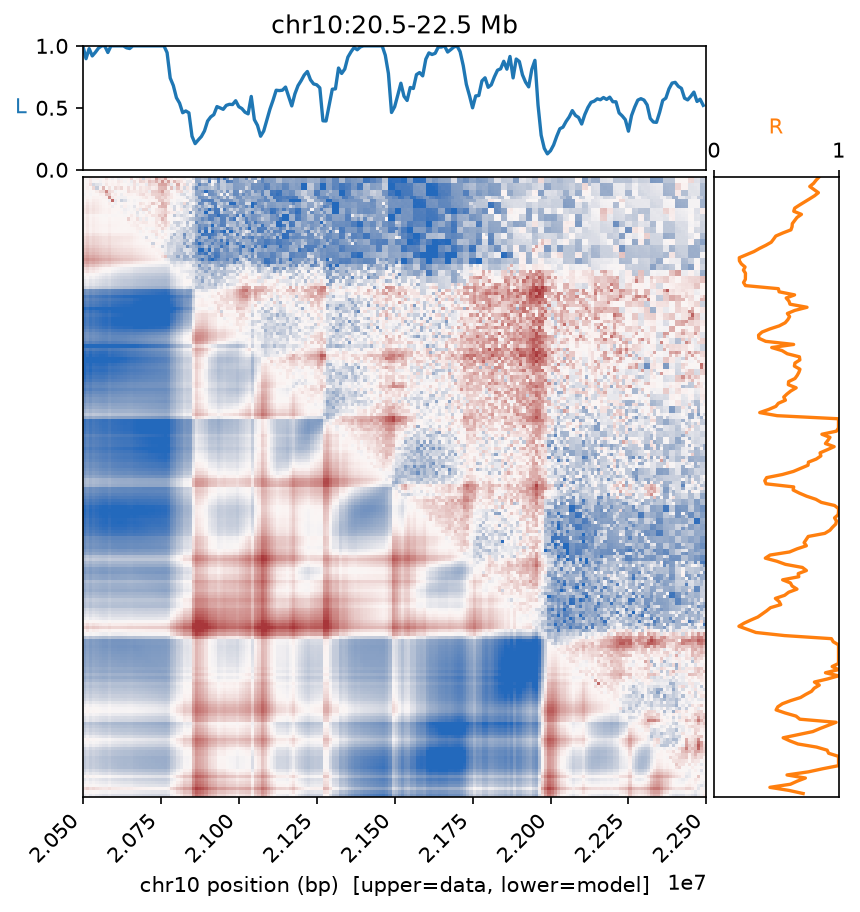

In [6]:
PATCH_START = 150   # local bin -> chr10:20.5 Mb
PATCH_SPAN  = 200    # 200 bins x 10 kb = 2 Mb -> chr10:20.5-22.5 Mb
REGION_LABEL = "chr10:20.5-22.5 Mb"

fig = plot_example_patch(fit, band, PATCH_START, PATCH_SPAN, RESOLUTION, "chr10", REGION_LABEL,
                    checkpoint=None, out="quick_start_patch.png", offset_bp=GENOMIC_OFFSET_BP)
plt.close(fig)
display(Image("quick_start_patch.png"))


## 6. Barrier vs CTCF, as its own figure

Two things worth separating from the CTCF alignment check above:

- **Plain CTCF, not CTCF+.** `ctcf_report` above splits by motif strand (`L`~CTCF+,
  `R`~CTCF-) because it compares each track individually. Here we're combining `L` and `R`
  into a single barrier number, so we pair it with the plain (non-strand-split) `CTCF`
  column from the comp table, rather than summing `CTCF_painted_pos` + `CTCF_painted_neg`.
- **`(1-L)+(1-R)`, not `(1-L)(1-R)`.** A CTCF site is usually single-orientation --
  it blocks *one* leg, not both -- so the barrier condition is an OR (either leg slows),
  not an AND. The product `(1-L)(1-R)` needs both legs to dip at once and stays near zero
  at an ordinary single-orientation site even when it's a real barrier; the sum doesn't
  have that blind spot.


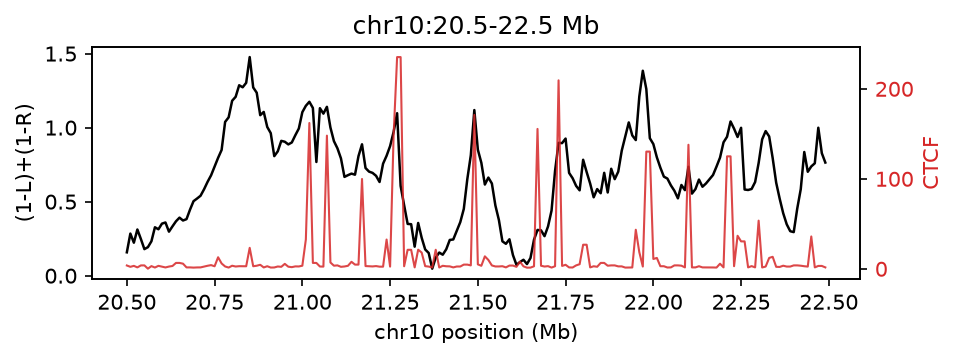

In [7]:
import pandas as pd

L, R = np.asarray(fit.L), np.asarray(fit.R)
barrier = (1 - L) + (1 - R)      # (1-L)+(1-R) -- either leg slows (OR)

_ctcf_table = pd.read_csv(CTCF_TSV, sep="\t")
ctcf_total = _ctcf_table.loc[_ctcf_table["chrID"] == CHROM, "CTCF"].to_numpy(np.float32)

window = slice(PATCH_START, PATCH_START + PATCH_SPAN)
coords_mb = GENOMIC_OFFSET_MB + np.arange(PATCH_START, PATCH_START + PATCH_SPAN) * RESOLUTION / 1e6

fig, ax = plt.subplots(figsize=(6.5, 2.5))
ax.plot(coords_mb, barrier[window], color="k", lw=1.2)
ax.set_ylabel("(1-L)+(1-R)")
ax_ctcf = ax.twinx()
ax_ctcf.plot(coords_mb, ctcf_total[window], color="tab:red", lw=1.0, alpha=0.85)
ax_ctcf.set_ylabel("CTCF", color="tab:red")
ax_ctcf.tick_params(axis="y", labelcolor="tab:red")

ax.set_title(REGION_LABEL)
ax.set_xlabel("chr10 position (Mb)")
fig.tight_layout()
out_png = "quick_start_barrier_ctcf.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(out_png))
